In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from PIL import Image, ImageFilter

folder_training_flat = "../data_sets/Landing/training/Flat/"
folder_training_rough = "../data_sets/Landing/training/Rough/"
folder_testing_flat = "../data_sets/Landing/testing/Flat/"
folder_testing_rough = "../data_sets/Landing/testing/Rough/"

def get_data(folder, im_width, im_length, label):
    file_names = os.listdir(folder)  # list of filenames in directory
    n_samples = len(file_names)
    x = np.empty((n_samples, im_width*im_length))
    y = np.empty((n_samples, 1))

    for i in range(n_samples):
        path = folder + file_names[i]
        im = Image.open(path).convert("L")
        im = im.resize((im_width, im_length))
        im_array = np.asarray(im)
        x[i, :] = im_array.reshape(1, -1)
        y[i, 0] = label

    return x, y

41 40


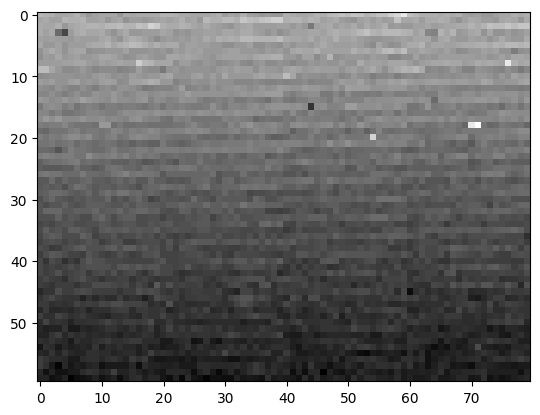

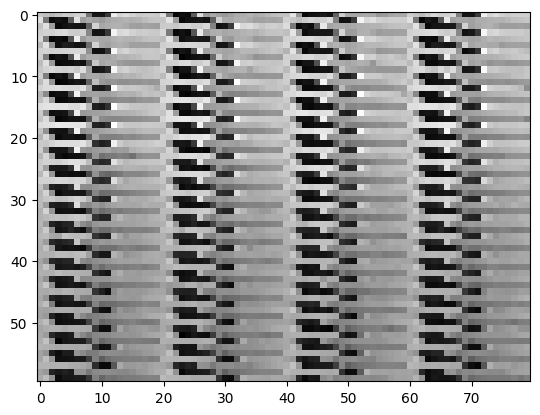

In [12]:
im_width = int(480/8)
im_length = int(640/8)

x_train_flat, y_train_flat = get_data(folder_training_flat, im_width, im_length, 0)
x_train_rough, y_train_rough = get_data(folder_training_rough, im_width, im_length, 1)
x_test_flat, y_test_flat = get_data(folder_testing_flat, im_width, im_length, 0)
x_test_rough, y_test_rough = get_data(folder_testing_rough, im_width, im_length, 1)

x_train = np.vstack((x_train_flat, x_train_rough))
x_test = np.vstack((x_test_flat, x_test_rough))
y_train = np.vstack((y_train_flat, y_train_rough))
y_test = np.vstack((y_test_flat, y_test_rough))

P_train = len(x_train[:, 0])
P_test = len(x_test[:, 0])
print(P_train, P_test)

plt.imshow(x_train_flat[0, :].reshape(im_width, im_length), cmap = "gray")
plt.show()
plt.imshow(x_train_rough[0, :].reshape(im_width, im_length), cmap = "gray")
plt.show()

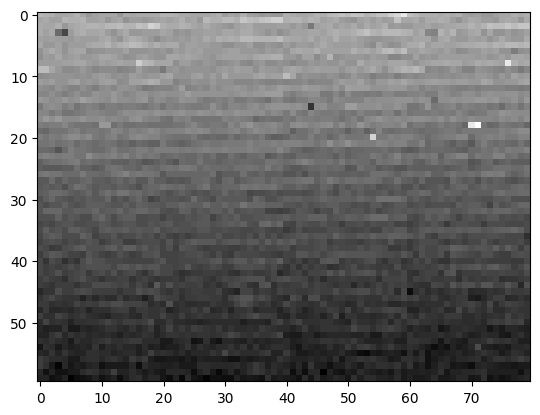

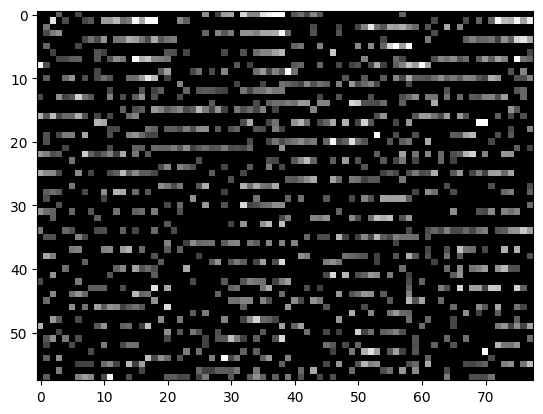

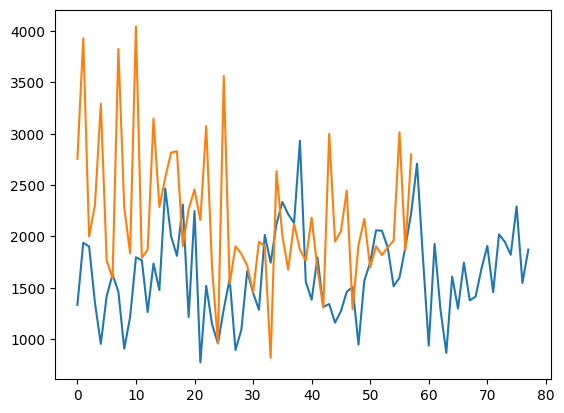

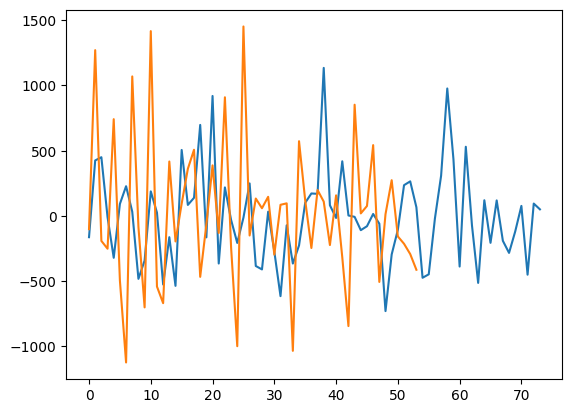

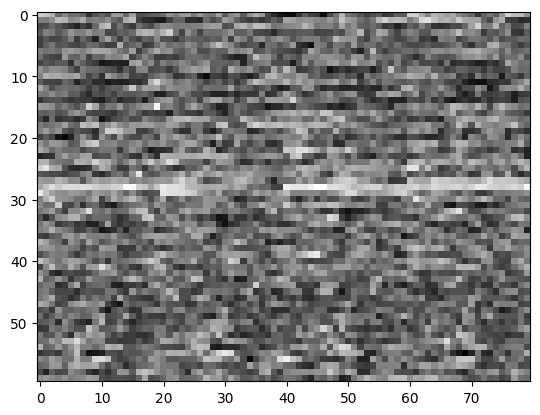

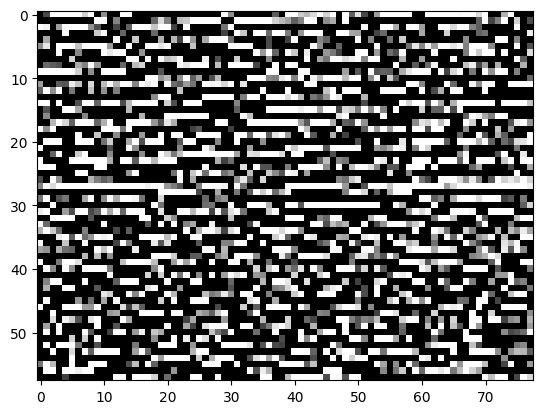

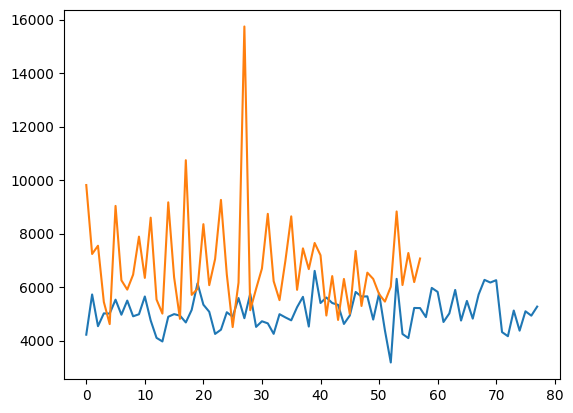

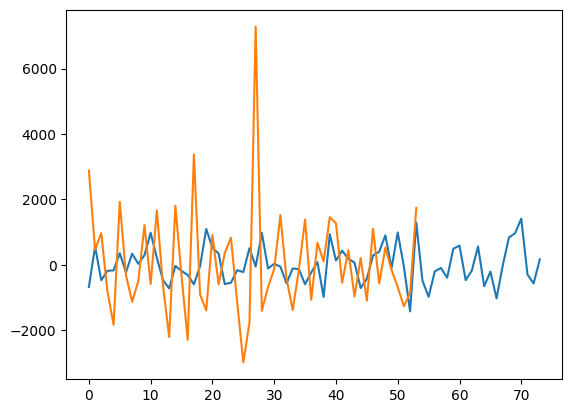

In [19]:
def process_image(image_array, edge_thresh):
    image_array = (image_array - np.min(image_array))*255/(np.max(image_array) - np.min(image_array))
    im = Image.fromarray(image_array.reshape(im_width, im_length)).convert("L")
    edges_image = im.filter(ImageFilter.FIND_EDGES)
    edges_array = np.asarray(edges_image).astype(float)

    # Remove outer edge around image due to issues detecting edges on border of image
    edges_array_scaled = edges_array.copy()[1:im_width - 1, 1:im_length - 1]
    # Set pixel below a given threshold to 0
    edges_array_scaled[edges_array_scaled < edge_thresh] = 0

    edges_v = np.sum(edges_array_scaled, axis = 0)
    edges_h = np.sum(edges_array_scaled, axis = 1)

    plt.imshow(image_array.reshape(im_width, im_length), cmap = "gray")
    plt.show()
    plt.imshow(edges_array_scaled.reshape(im_width - 2, im_length - 2), cmap = "gray")
    plt.show()
    plt.plot(edges_v)
    plt.plot(edges_h)
    plt.show()

    M = 5
    f = np.insert( np.zeros(M-1), M-1, 1, axis = 0) - (1/M)*np.ones(M)
    edges_v = np.convolve(edges_v, f, mode = "valid")
    edges_h = np.convolve(edges_h, f, mode = "valid")

    plt.plot(edges_v)
    plt.plot(edges_h)
    plt.show()

ET = 64
process_image(x_train[0, :], ET)
process_image(x_train[20, :], ET)